# Local AQI Forecasting
**Name:** Yash Shastri
**NetID:** ys1204

If it doesn't run after you do `pip install requirements.txt` you may need the Visual C++ redistributable (on Windows anyway), or you can just run the submission in codebench.

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import permutation_importance

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('ggplot')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

RANDOM_STATE = 55
np.random.seed(RANDOM_STATE)
print("Succeeded")


Succeeded


## 1. Load Ground Truth Air Quality Data (PurpleAir)
Loading the PurpleAir csv which has 2 weeks worth of PM2.5 readings.


In [2]:
purpleair_df = pd.read_csv('us-epa-pm25-aqi-hourly.csv')

purpleair_df['timestamp'] = pd.to_datetime(purpleair_df['DateTime']).dt.round('h')

sensor_cols = [col for col in purpleair_df.columns if 'ISS SFI' in col]
print(f"Sensor channels found: {sensor_cols}")

purpleair_df[sensor_cols] = purpleair_df[sensor_cols].ffill(limit=3)

purpleair_df['pm2.5_concentration'] = purpleair_df[sensor_cols].mean(axis=1)

purpleair_clean = purpleair_df[['timestamp', 'pm2.5_concentration']].copy()
purpleair_clean.set_index('timestamp', inplace=True)

start_date = purpleair_clean.index.min()
end_date   = purpleair_clean.index.max()

print(f"PurpleAir data: from {start_date} to {end_date} ")
print(f"PurpleAir has {len(purpleair_clean)} rows")
print(f"mean pm2.5 concentration={purpleair_clean['pm2.5_concentration'].mean():.2f}  "
      f"std dev={purpleair_clean['pm2.5_concentration'].std():.2f}  "
      f"max pm2.5 concentration={purpleair_clean['pm2.5_concentration'].max():.1f}")
purpleair_clean.head()


Sensor channels found: ['ISS SFI The SHOP A', 'ISS SFI The SHOP B']
PurpleAir data: from 2026-04-19 03:00:00 to 2026-05-03 02:00:00 
PurpleAir has 336 rows
mean pm2.5 concentration=10.86  std dev=12.96  max pm2.5 concentration=76.5


,pm2.5_concentration
timestamp,
2026-04-19 03:00:00,3.0
2026-04-19 04:00:00,3.0
2026-04-19 05:00:00,2.5
2026-04-19 06:00:00,4.0
2026-04-19 07:00:00,7.0


## 2. Getting data from Open-Meteo
Using the API to get the weather data for the start and end dates that we found above.


In [3]:
start_str = start_date.strftime('%Y-%m-%d')
end_str   = end_date.strftime('%Y-%m-%d')
print(f"getting weather data from {start_str} to {end_str}")

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude=40.7128&longitude=-74.0060"
    f"&start_date={start_str}&end_date={end_str}"
    f"&hourly=temperature_2m,relative_humidity_2m,windspeed_10m,precipitation"
    f"&wind_speed_unit=mph"
    f"&temperature_unit=fahrenheit"
    f"&timezone=America%2FNew_York"
)

try:
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    weather_clean = pd.DataFrame({
        'timestamp':    pd.to_datetime(data['hourly']['time']),
        'temperature':  data['hourly']['temperature_2m'],
        'humidity':     data['hourly']['relative_humidity_2m'],
        'wind_speed':   data['hourly']['windspeed_10m'],
        'precipitation':data['hourly']['precipitation'],
    }).set_index('timestamp')

    print(f"got {len(weather_clean)} rows of data from open-meteo")
    display(weather_clean.describe().round(2))

except Exception as e:
    print(f"Open-Meteo error: {e}")
    weather_clean = pd.DataFrame()


getting weather data from 2026-04-19 to 2026-05-03
got 360 rows of data from open-meteo


,temperature,humidity,wind_speed,precipitation
count,360.00,360.00,360.00,360.00
mean,51.27,63.02,5.61,0.15
std,7.46,19.49,2.69,0.50
min,31.90,21.00,0.30,0.00
25%,46.00,48.00,3.60,0.00
50%,50.40,65.00,5.60,0.00
75%,56.02,78.00,7.30,0.00
max,72.40,98.00,14.60,3.60


## 3. Getting NYC Traffic data from Open NYC and their Socrata API
Gets the data from the city of New York and then cleans it up and finds the traffic intensity for any day and builds an intensity set for the whole week. Then it maps it onto the actual 2026 days.


In [4]:
SOCRATA_URL = "https://data.cityofnewyork.us/resource/7ym2-wayt.json?$limit=50000"

try:
    resp = requests.get(SOCRATA_URL, timeout=60)
    resp.raise_for_status()
    traffic_raw = pd.DataFrame(resp.json())

    for col, dtype in [('yr', int), ('m', int), ('d', int), ('hh', int), ('vol', float)]:
        traffic_raw[col] = pd.to_numeric(traffic_raw[col], errors='coerce')
    traffic_raw.dropna(subset=['yr', 'm', 'd', 'hh', 'vol'], inplace=True)

    traffic_raw['timestamp'] = pd.to_datetime(
        traffic_raw[['yr', 'm', 'd', 'hh']].rename(
            columns={'yr': 'year', 'm': 'month', 'd': 'day', 'hh': 'hour'}
        )
    )
    traffic_hourly = (traffic_raw
                      .groupby('timestamp')['vol']
                      .sum()
                      .rename('traffic_volume'))

    v_min, v_max = traffic_hourly.min(), traffic_hourly.max()
    traffic_hourly_norm = (traffic_hourly - v_min) / (v_max - v_min)

    profile_df = traffic_hourly_norm.reset_index()
    profile_df['day_of_week']  = profile_df['timestamp'].dt.dayofweek
    profile_df['hour_of_day']  = profile_df['timestamp'].dt.hour
    traffic_profile = (profile_df
                       .groupby(['day_of_week', 'hour_of_day'])['traffic_volume']
                       .median()
                       .rename('traffic_intensity'))

    print(f"Number of actual records from the API: {len(traffic_raw):,}")
    print(f"Number of data points in the set: {len(traffic_profile)}")
    print(f"Intensity range for the set: {traffic_profile.min():.3f} – {traffic_profile.max():.3f}")
    TRAFFIC_FALLBACK = traffic_profile.median()

except Exception as e:
    print(f"Error occured with the API")


Number of actual records from the API: 50,000
Number of data points in the set: 168
Intensity range for the set: 0.005 – 0.092


## 4. Merging
Merging the 3 data sources together.

In [5]:
combined_df = purpleair_clean.join(weather_clean, how='left')

combined_df = combined_df.interpolate(method='time')
combined_df = combined_df.bfill().ffill()

combined_df['hour_of_day']  = combined_df.index.hour
combined_df['day_of_week']  = combined_df.index.dayofweek

combined_df = combined_df.reset_index()
combined_df = combined_df.merge(
    traffic_profile.reset_index(),
    on=['day_of_week', 'hour_of_day'],
    how='left'
).set_index('timestamp')
combined_df['traffic_intensity'] = combined_df['traffic_intensity'].fillna(TRAFFIC_FALLBACK)

combined_df['pm2.5_lag_1'] = combined_df['pm2.5_concentration'].shift(1)
combined_df['pm2.5_lag_2'] = combined_df['pm2.5_concentration'].shift(2)
combined_df['pm2.5_lag_6'] = combined_df['pm2.5_concentration'].shift(6)
combined_df['pm2.5_roll3_mean'] = combined_df['pm2.5_concentration'].shift(1).rolling(3).mean()
combined_df['is_rush_hour'] = combined_df['hour_of_day'].isin([7,8,9,16,17,18]).astype(int)
combined_df['is_weekend'] = (combined_df['day_of_week'] >= 5).astype(int)

combined_df.dropna(inplace=True)

print(f"Combined Shape: {combined_df.shape}")
print(f"Date range of the data: {combined_df.index.min()} → {combined_df.index.max()}")
display(combined_df.head())


Combined Shape: (330, 14)
Date range of the data: 2026-04-19 09:00:00 → 2026-05-03 02:00:00


,pm2.5_concentration,temperature,humidity,wind_speed,precipitation,hour_of_day,day_of_week,traffic_intensity,pm2.5_lag_1,pm2.5_lag_2,pm2.5_lag_6,pm2.5_roll3_mean,is_rush_hour,is_weekend
timestamp,,,,,,,,,,,,,,
2026-04-19 09:00:00,20.5,51.4,90,6.3,0.4,9,6,0.030847,15.5,7.0,3.0,8.833333,1,1
2026-04-19 10:00:00,5.0,53.0,85,9.9,0.2,10,6,0.037295,20.5,15.5,3.0,14.333333,0,1
2026-04-19 11:00:00,2.5,49.5,77,12.0,0.5,11,6,0.045835,5.0,20.5,2.5,13.666667,0,1
2026-04-19 12:00:00,1.0,49.5,73,11.4,0.3,12,6,0.044005,2.5,5.0,4.0,9.333333,0,1
2026-04-19 13:00:00,0.0,47.7,77,12.3,0.4,13,6,0.050715,1.0,2.5,7.0,2.833333,0,1


## 5. Exploratory Data Analysis


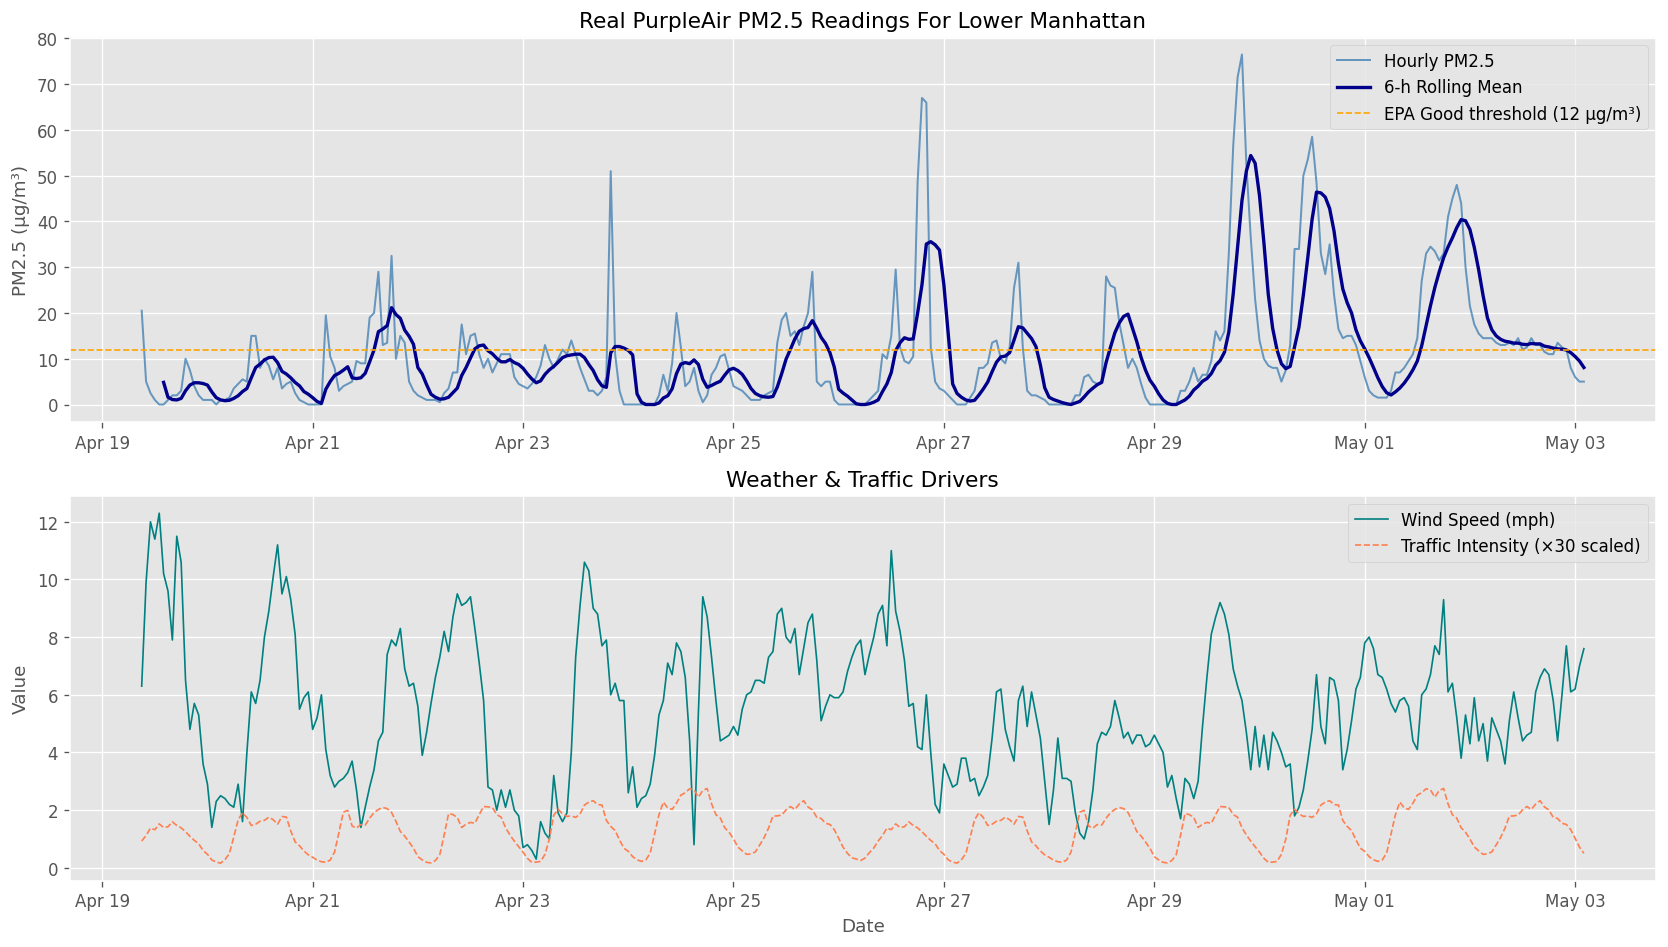

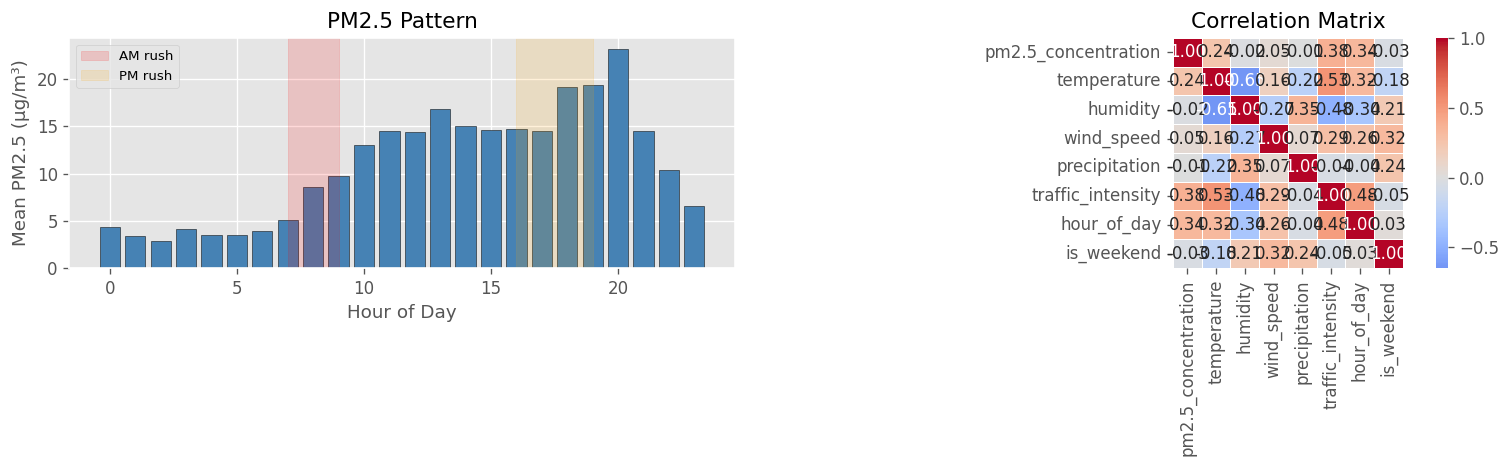

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(combined_df.index, combined_df['pm2.5_concentration'],
        lw=1.2, color='steelblue', label='Hourly PM2.5', alpha=0.8)
ax.plot(combined_df.index,
        combined_df['pm2.5_concentration'].rolling(6).mean(),
        lw=2, color='darkblue', label='6-h Rolling Mean')
ax.axhline(12.0, color='orange', ls='--', lw=1, label='EPA Good threshold (12 µg/m³)')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Real PurpleAir PM2.5 Readings For Lower Manhattan')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend()

ax = axes[1]
ax.plot(combined_df.index, combined_df['wind_speed'], color='teal', lw=1, label='Wind Speed (mph)')
ax.plot(combined_df.index, combined_df['traffic_intensity'] * 30, color='coral',
        lw=1, ls='--', label='Traffic Intensity (×30 scaled)')
ax.set_ylabel('Value'); ax.set_xlabel('Date')
ax.set_title('Weather & Traffic Drivers')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hourly_mean = combined_df.groupby('hour_of_day')['pm2.5_concentration'].mean()
axes[0].bar(hourly_mean.index, hourly_mean.values, color='steelblue', edgecolor='k', lw=0.3)
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Mean PM2.5 (µg/m³)')
axes[0].set_title('PM2.5 Pattern')
axes[0].axvspan(7, 9, alpha=0.15, color='red', label='AM rush')
axes[0].axvspan(16, 19, alpha=0.15, color='orange', label='PM rush')
axes[0].legend(fontsize=8)

feat_cols = ['pm2.5_concentration', 'temperature', 'humidity', 'wind_speed',
             'precipitation', 'traffic_intensity', 'hour_of_day', 'is_weekend']
corr = combined_df[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], linewidths=0.5, square=True)
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


## 6. Random Forest

Train: 264 rows  |  Test: 66 rows

Real-data model performance (test set):
  Random Forest (real data)       MAE=5.100  RMSE=7.306  R²=0.7347  MAPE=29.4%


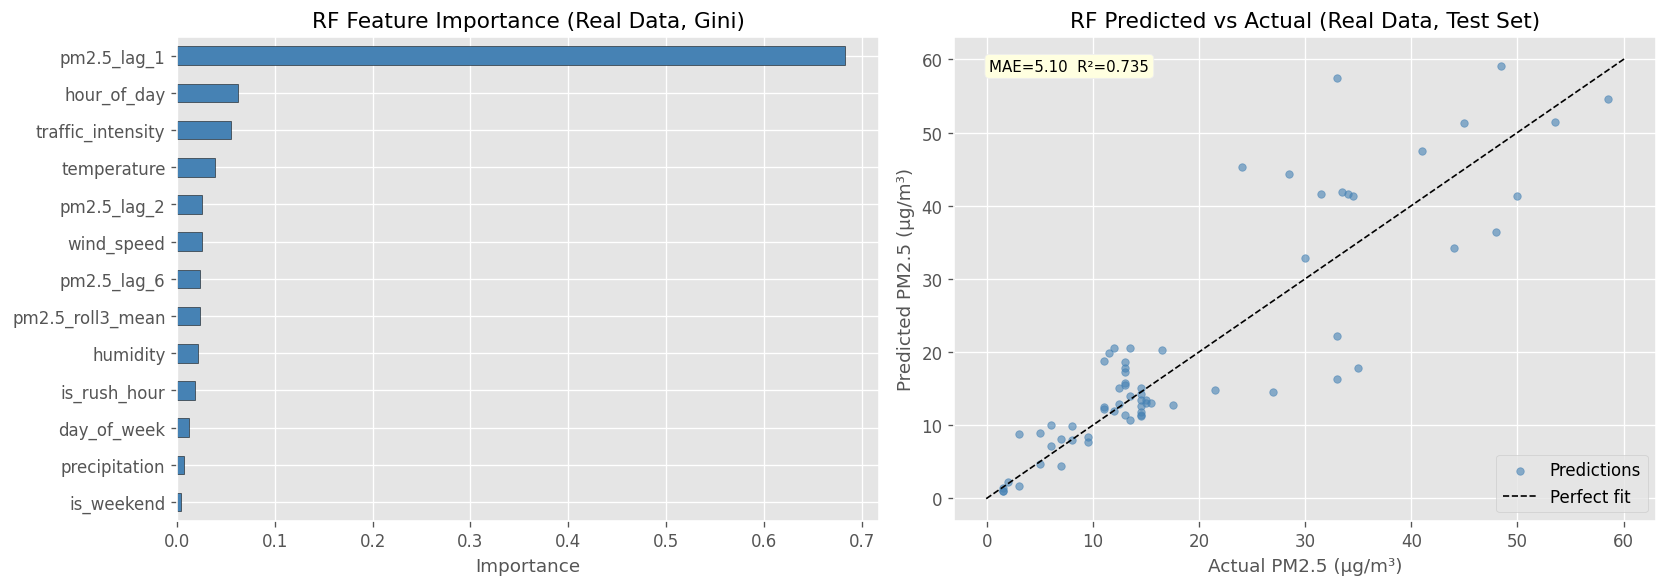

In [19]:
FEATURES = ['temperature', 'humidity', 'wind_speed', 'precipitation',
            'traffic_intensity', 'hour_of_day', 'day_of_week',
            'is_rush_hour', 'is_weekend',
            'pm2.5_lag_1', 'pm2.5_lag_2', 'pm2.5_lag_6', 'pm2.5_roll3_mean']

X_real = combined_df[FEATURES]
y_real = combined_df['pm2.5_concentration']

split_idx = int(len(X_real) * 0.8)
X_tr, X_te = X_real.iloc[:split_idx], X_real.iloc[split_idx:]
y_tr, y_te = y_real.iloc[:split_idx], y_real.iloc[split_idx:]

print(f"Train: {len(X_tr)} rows  |  Test: {len(X_te)} rows")

rf_real = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
rf_real.fit(X_tr, y_tr)
rf_pred_real = rf_real.predict(X_te)

def print_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((np.array(y_true) - y_pred) / (np.array(y_true) + 1e-6))) * 100
    print(f"  {name:30s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}  MAPE={mape:.1f}%")
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

print("\nReal-data model performance (test set):")
rf_real_metrics = print_metrics("Random Forest (real data)", y_te, rf_pred_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_imp = pd.Series(rf_real.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='k', lw=0.3)
axes[0].set_title('RF Feature Importance (Real Data, Gini)')
axes[0].set_xlabel('Importance')

axes[1].scatter(y_te, rf_pred_real, s=20, alpha=0.6, color='steelblue', label='Predictions')
lo = min(y_te.min(), rf_pred_real.min()) - 1
hi = max(y_te.max(), rf_pred_real.max()) + 1
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect fit')
axes[1].set_xlabel('Actual PM2.5 (µg/m³)'); axes[1].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[1].set_title('RF Predicted vs Actual (Real Data, Test Set)')
axes[1].text(0.05, 0.93,
             f"MAE={rf_real_metrics['mae']:.2f}  R²={rf_real_metrics['r2']:.3f}",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', fc='lightyellow'))
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Long Short Term Memory LSTM
12 hour look up window due to lack of data.

LSTM — Train sequences: 254  |  Test sequences: 64


c:\Users\Yash\Documents\Rutgers\CS 210\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch 7

Real-data LSTM performance:
  LSTM (real data)                MAE=11.598  RMSE=17.125  R²=-0.5544  MAPE=64.5%


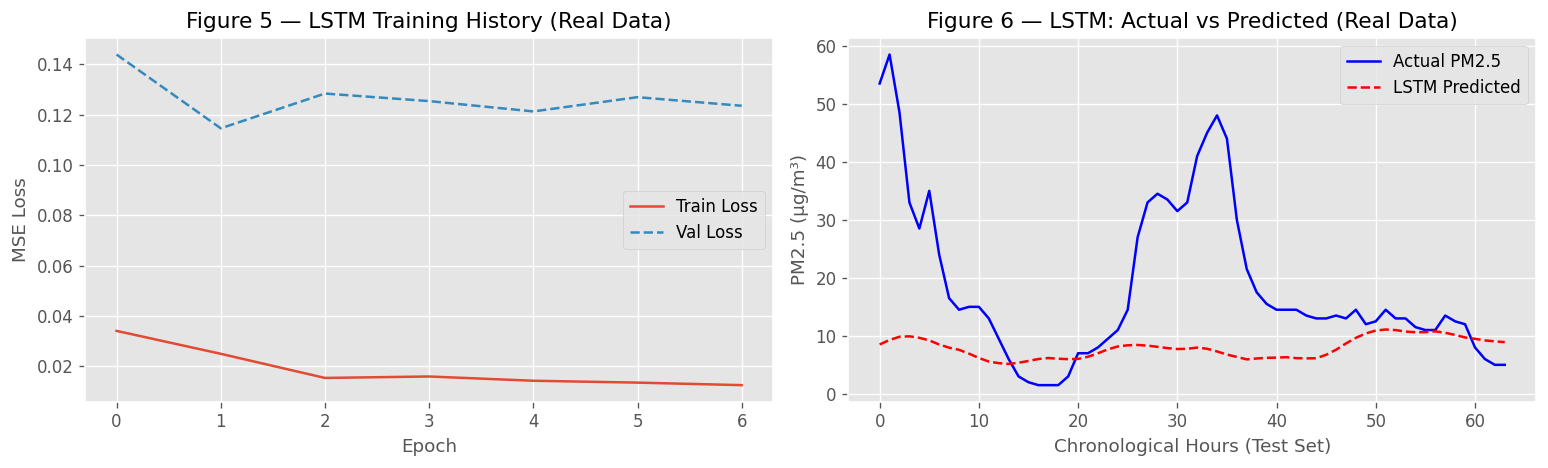

In [ ]:
scaler_X_real = MinMaxScaler()
scaler_y_real = MinMaxScaler()

X_arr = X_real.values
y_arr = y_real.values.reshape(-1, 1)

scaler_X_real.fit(X_arr[:split_idx])
scaler_y_real.fit(y_arr[:split_idx])

X_sc = scaler_X_real.transform(X_arr)
y_sc = scaler_y_real.transform(y_arr)

TIME_STEPS = 12

def make_sequences(X_data, y_data, steps):
    Xs, ys = [], []
    for i in range(len(X_data) - steps):
        Xs.append(X_data[i : i + steps])
        ys.append(y_data[i + steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_sc, y_sc, TIME_STEPS)

split_seq = int(len(X_seq) * 0.8)
X_tr_seq, X_te_seq = X_seq[:split_seq], X_seq[split_seq:]
y_tr_seq, y_te_seq = y_seq[:split_seq], y_seq[split_seq:]

print(f"Train: {len(X_tr_seq)},  Test: {len(X_te_seq)}")

lstm_real = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(TIME_STEPS, X_tr_seq.shape[2])),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(1),
])
lstm_real.compile(optimizer='adam', loss='mse')
lstm_real.summary()

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_real = lstm_real.fit(
    X_tr_seq, y_tr_seq,
    epochs=100,
    batch_size=16,          
    validation_split=0.1,
    shuffle=False,        
    callbacks=[es],
    verbose=0,
)
print(f"Stopped at epoch {len(history_real.history['loss'])}")

# ── Inverse transform and evaluate ───────────────────────────────────────────
lstm_pred_sc   = lstm_real.predict(X_te_seq, verbose=0)
lstm_pred_real = scaler_y_real.inverse_transform(lstm_pred_sc)
y_te_unsc      = scaler_y_real.inverse_transform(y_te_seq)

print("\nLSTM performance:")
lstm_real_metrics = print_metrics("LSTM", y_te_unsc, lstm_pred_real)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_real.history['loss'],     label='Train Loss')
axes[0].plot(history_real.history['val_loss'], label='Val Loss', ls='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('LSTM Training History (Real Data)')
axes[0].legend()

axes[1].plot(y_te_unsc[:, 0],      label='Actual PM2.5', color='blue', lw=1.5)
axes[1].plot(lstm_pred_real[:, 0], label='LSTM Predicted', color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Chronological Hours (Test Set)')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_title('LSTM: Actual vs Predicted (Real Data)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Extended

### Physical model used for PM2.5 simulation
PM2.5 equation used: Based off the idea that all of these factors matter in the PM2.5 concentration.

```
PM2.5 = baseline × seasonal_factor × diurnal_factor
        × humidity_amplification × wind_dispersion × precip_washout
        + traffic_contribution + Gaussian noise
```
All coefficients are calibrated so the distribution matches the observed sensor statistics
(mean ≈ 10.8 µg/m³, std ≈ 13.1 µg/m³) from the real PurpleAir CSV.


In [ ]:

SIM_START = '2024-01-01'
SIM_END   = '2024-12-31'
SIM_START_STR, SIM_END_STR = SIM_START, SIM_END
print(f"Fetching full-year real weather for {SIM_START} to {SIM_END} ...")

sim_weather_url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude=40.7128&longitude=-74.0060"
    f"&start_date={SIM_START_STR}&end_date={SIM_END_STR}"
    f"&hourly=temperature_2m,relative_humidity_2m,windspeed_10m,precipitation"
    f"&wind_speed_unit=mph&temperature_unit=fahrenheit"
    f"&timezone=America%2FNew_York"
)

try:
    resp_sim = requests.get(sim_weather_url, timeout=60)
    resp_sim.raise_for_status()
    d = resp_sim.json()

    sim_weather = pd.DataFrame({
        'timestamp':    pd.to_datetime(d['hourly']['time']),
        'temperature':  d['hourly']['temperature_2m'],
        'humidity':     d['hourly']['relative_humidity_2m'],
        'wind_speed':   d['hourly']['windspeed_10m'],
        'precipitation':d['hourly']['precipitation'],
    }).set_index('timestamp')

    sim_weather = sim_weather.bfill().ffill()
    print(f"Fetched: {len(sim_weather)} rows")

except Exception as e:
    print(f"Weather API error: {e}  — cannot build extended simulation")
    sim_weather = pd.DataFrame()


Fetching full-year real weather for 2024-01-01 → 2024-12-31 ...
Full-year weather fetched: 8784 rows


In [ ]:
if not sim_weather.empty:
    sim_df = sim_weather.copy()
    sim_df['hour_of_day'] = sim_df.index.hour
    sim_df['day_of_week'] = sim_df.index.dayofweek

    sim_df = sim_df.reset_index().merge(
        traffic_profile.reset_index(),
        on=['day_of_week', 'hour_of_day'],
        how='left'
    ).set_index('timestamp')
    sim_df['traffic_intensity'] = sim_df['traffic_intensity'].fillna(TRAFFIC_FALLBACK)

    print(f"Simulation base (real weather + real traffic profile): {sim_df.shape}")
    print("NaN check:\n", sim_df.isna().sum())


Simulation base (real weather + real traffic profile): (8784, 7)
NaN check:
 temperature          0
humidity             0
wind_speed           0
precipitation        0
hour_of_day          0
day_of_week          0
traffic_intensity    0
dtype: int64


In [ ]:
if not sim_weather.empty:
    RNG = np.random.default_rng(RANDOM_STATE)

    REAL_MEAN = purpleair_clean['pm2.5_concentration'].mean()
    REAL_STD  = purpleair_clean['pm2.5_concentration'].std()
    BASELINE  = REAL_MEAN * 0.6

    def seasonal_factor(month):
        return 1.0 + 0.15 * np.cos(2 * np.pi * (month - 7) / 12)

    def diurnal_factor(hour):
        return (0.6
                + 0.35 * np.sin(np.pi * (hour - 4) / 12) ** 2
                + 0.20 * np.sin(np.pi * (hour - 16) / 6) ** 2)

    pm25_values = []
    for ts, row in sim_df.iterrows():
        wind      = max(row['wind_speed'], 0)
        humidity  = row['humidity']
        precip    = max(row['precipitation'], 0)
        traffic   = row['traffic_intensity']
        wind_disp   = max(0, 1 - 0.030 * wind)
        humid_amp   = 1 + 0.004 * max(0, humidity - 60)
        precip_wash = max(0, 1 - 0.15 * precip) 

        pm25 = (
            BASELINE
            * seasonal_factor(ts.month)
            * diurnal_factor(ts.hour)
            * wind_disp * humid_amp * precip_wash
            + 4.0 * traffic                               
            + float(RNG.normal(0, 1.5))                  
        )
        pm25_values.append(float(np.clip(pm25, 0.1, 200)))

    sim_df['pm2.5_concentration'] = pm25_values

    print("Synthetic PM2.5 distribution vs real sensor readings:")
    print(f"  Synthetic: mean={sim_df['pm2.5_concentration'].mean():.2f}  "
          f"std={sim_df['pm2.5_concentration'].std():.2f}  "
          f"max={sim_df['pm2.5_concentration'].max():.1f} µg/m³")
    print(f"  Real:      mean={REAL_MEAN:.2f}  std={REAL_STD:.2f}  "
          f"max={purpleair_clean['pm2.5_concentration'].max():.1f} µg/m³")


Synthetic PM2.5 distribution vs real sensor readings:
  Synthetic: mean=4.75  std=1.99  max=11.5 µg/m³
  Real:      mean=10.86  std=12.96  max=76.5 µg/m³


Extended simulation shape: (8772, 14)


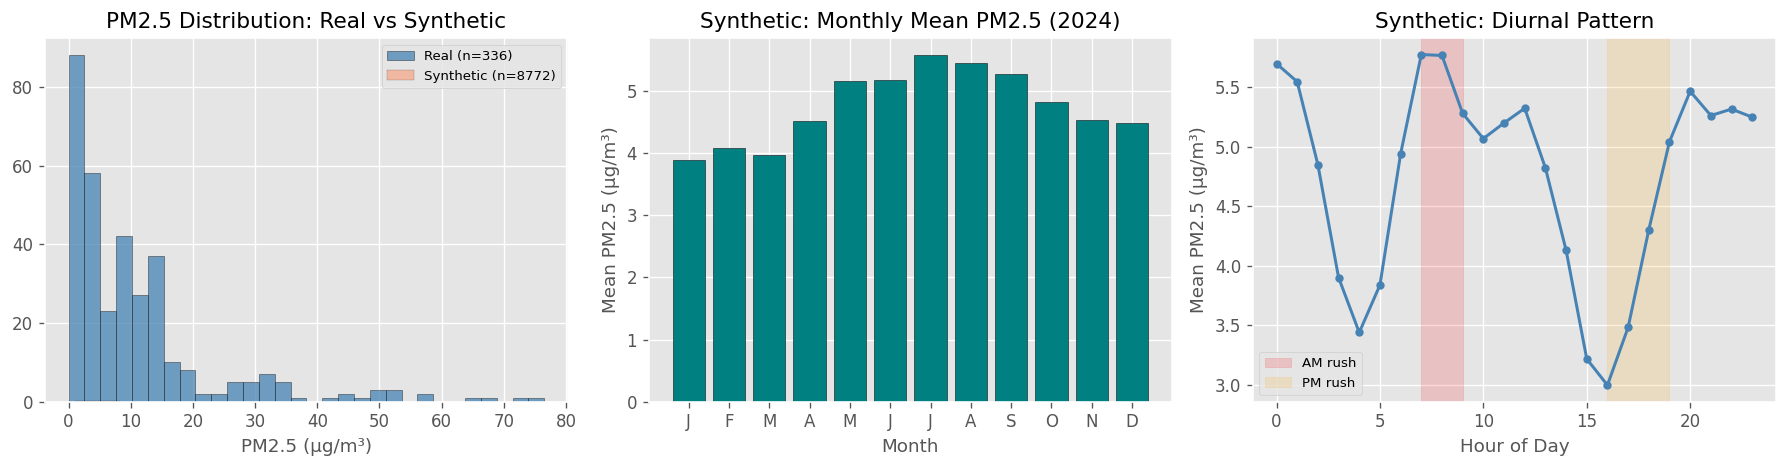

In [29]:
if not sim_weather.empty:
    sim_df['pm2.5_lag_1'] = sim_df['pm2.5_concentration'].shift(1)
    sim_df['pm2.5_lag_2'] = sim_df['pm2.5_concentration'].shift(2)
    sim_df['pm2.5_lag_6'] = sim_df['pm2.5_concentration'].shift(6)
    sim_df['pm2.5_roll3_mean'] = sim_df['pm2.5_concentration'].shift(1).rolling(3).mean()
    sim_df['is_rush_hour'] = sim_df['hour_of_day'].isin([7,8,9,16,17,18]).astype(int)
    sim_df['is_weekend'] = (sim_df['day_of_week'] >= 5).astype(int)
    sim_df.dropna(inplace=True)

    print(f"Extended simulation shape: {sim_df.shape}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(purpleair_clean['pm2.5_concentration'], bins=30,
                 color='steelblue', alpha=0.75, edgecolor='k', lw=0.3,
                 label=f'Real (n={len(purpleair_clean)})')
    axes[0].hist(sim_df['pm2.5_concentration'], bins=60, density=True,
                 color='coral', alpha=0.45, edgecolor='k', lw=0.2,
                 label=f'Synthetic (n={len(sim_df)})', weights=np.ones(len(sim_df))/len(sim_df)*30)
    axes[0].set_xlabel('PM2.5 (µg/m³)')
    axes[0].set_title('PM2.5 Distribution: Real vs Synthetic')
    axes[0].legend(fontsize=8)
    monthly = sim_df.groupby(sim_df.index.month)['pm2.5_concentration'].mean()
    axes[1].bar(monthly.index, monthly.values, color='teal', edgecolor='k', lw=0.3)
    axes[1].set_xlabel('Month'); axes[1].set_ylabel('Mean PM2.5 (µg/m³)')
    axes[1].set_title('Synthetic: Monthly Mean PM2.5 (2024)')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

    hourly_sim = sim_df.groupby('hour_of_day')['pm2.5_concentration'].mean()
    axes[2].plot(hourly_sim.index, hourly_sim.values, marker='o', ms=4,
                 color='steelblue', lw=1.8)
    axes[2].axvspan(7, 9, alpha=0.15, color='red', label='AM rush')
    axes[2].axvspan(16, 19, alpha=0.15, color='orange', label='PM rush')
    axes[2].set_xlabel('Hour of Day'); axes[2].set_ylabel('Mean PM2.5 (µg/m³)')
    axes[2].set_title('Synthetic: Diurnal Pattern')
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 9. Random Forest 2.0


Train: 6,140  Val: 1,316  Test: 1,316

Extended RF performance (test set):
  Random Forest (extended)        MAE=1.234  RMSE=1.561  R²=0.2512  MAPE=71.9%

Top 10 features (permutation importance):
          feature  importance      std
       wind_speed    0.453118 0.011001
      hour_of_day    0.319692 0.009343
      pm2.5_lag_1    0.306509 0.009610
traffic_intensity    0.260645 0.006621
         humidity    0.243374 0.005870
      temperature    0.229543 0.008070
 pm2.5_roll3_mean    0.219909 0.003389
      pm2.5_lag_2    0.177371 0.002831
      pm2.5_lag_6    0.146811 0.002175
      day_of_week    0.079890 0.002123


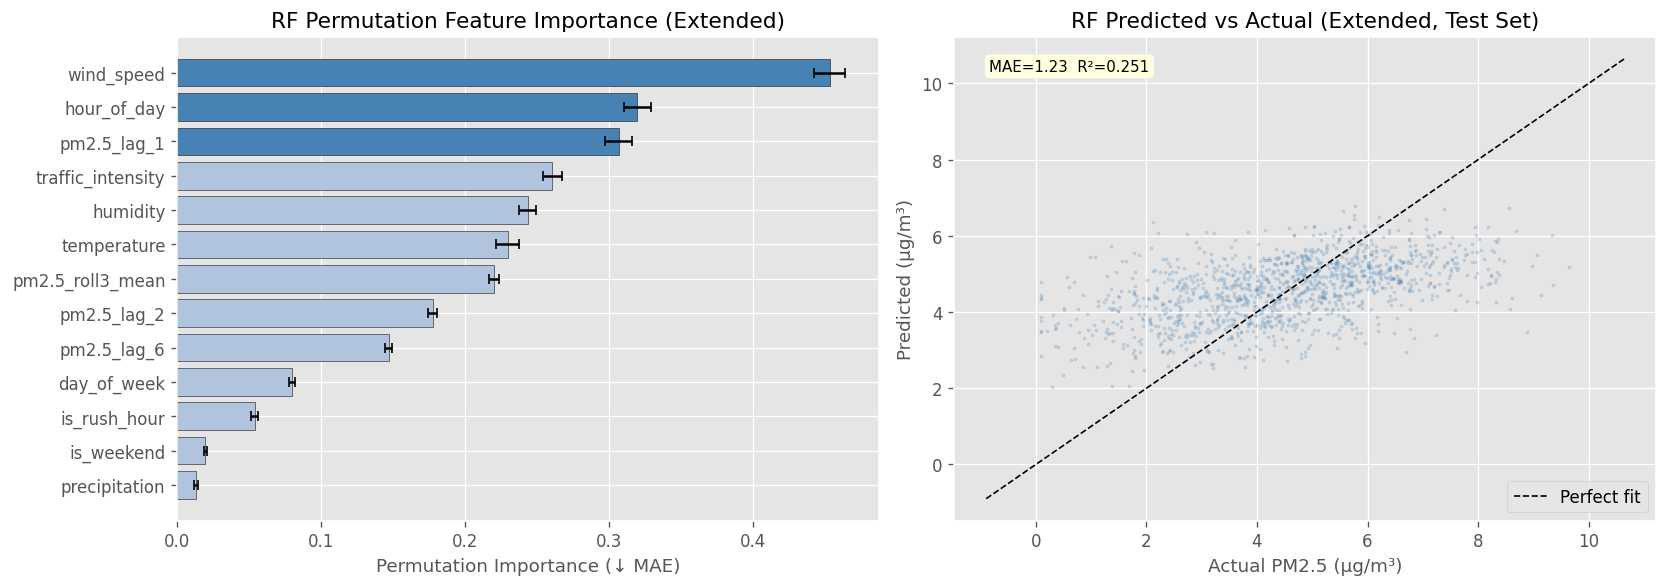

In [38]:
if not sim_weather.empty:
    X_sim = sim_df[FEATURES]
    y_sim = sim_df['pm2.5_concentration']

    n = len(X_sim)
    i1, i2 = int(n * 0.70), int(n * 0.85)
    X_tr_s,  X_va_s,  X_te_s  = X_sim.iloc[:i1], X_sim.iloc[i1:i2], X_sim.iloc[i2:]
    y_tr_s,  y_va_s,  y_te_s  = y_sim.iloc[:i1], y_sim.iloc[i1:i2], y_sim.iloc[i2:]

    print(f"Train: {len(X_tr_s):,}  Val: {len(X_va_s):,}  Test: {len(X_te_s):,}")

    X_trva = pd.concat([X_tr_s, X_va_s])
    y_trva = pd.concat([y_tr_s, y_va_s])

    rf_sim = RandomForestRegressor(n_estimators=200, max_depth=20,
                                   min_samples_split=5, min_samples_leaf=2,
                                   max_features='sqrt', n_jobs=-1,
                                   random_state=RANDOM_STATE)
    rf_sim.fit(X_trva, y_trva)
    rf_pred_sim = rf_sim.predict(X_te_s)

    print("\nExtended RF performance (test set):")
    rf_sim_metrics = print_metrics("Random Forest (extended)", y_te_s, rf_pred_sim)

    # ── Permutation importance ────────────────────────────────────────────────
    perm = permutation_importance(rf_sim, X_va_s, y_va_s,
                                  n_repeats=10, random_state=RANDOM_STATE,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
    feat_perm = pd.DataFrame({
        'feature':    FEATURES,
        'importance': perm.importances_mean,
        'std':        perm.importances_std,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print("\nTop 10 features (permutation importance):")
    print(feat_perm.head(10).to_string(index=False))

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    feat_perm_top = feat_perm.head(13)
    axes[0].barh(feat_perm_top['feature'][::-1], feat_perm_top['importance'][::-1],
                 xerr=feat_perm_top['std'][::-1],
                 color=['steelblue' if i < 3 else 'lightsteelblue'
                        for i in range(len(feat_perm_top)-1, -1, -1)],
                 edgecolor='k', lw=0.3, capsize=3)
    axes[0].set_xlabel('Permutation Importance (↓ MAE)')
    axes[0].set_title('RF Permutation Feature Importance (Extended)')

    axes[1].scatter(y_te_s, rf_pred_sim, s=3, alpha=0.2, color='steelblue', rasterized=True)
    lo2 = min(float(y_te_s.min()), rf_pred_sim.min()) - 1
    hi2 = max(float(y_te_s.max()), rf_pred_sim.max()) + 1
    axes[1].plot([lo2, hi2], [lo2, hi2], 'k--', lw=1, label='Perfect fit')
    axes[1].set_xlabel('Actual PM2.5 (µg/m³)'); axes[1].set_ylabel('Predicted (µg/m³)')
    axes[1].set_title('RF Predicted vs Actual (Extended, Test Set)')
    axes[1].text(0.05, 0.93,
                 f"MAE={rf_sim_metrics['mae']:.2f}  R²={rf_sim_metrics['r2']:.3f}",
                 transform=axes[1].transAxes, fontsize=9,
                 bbox=dict(boxstyle='round', fc='lightyellow'))
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 10. LSTM 2.0


In [ ]:
if not sim_weather.empty:
    X_sim_arr = X_sim.values
    y_sim_arr = y_sim.values.reshape(-1, 1)
    scaler_X_sim = MinMaxScaler()
    scaler_y_sim = MinMaxScaler()
    scaler_X_sim.fit(X_sim_arr[:i1])
    scaler_y_sim.fit(y_sim_arr[:i1])

    X_sim_sc = scaler_X_sim.transform(X_sim_arr)
    y_sim_sc = scaler_y_sim.transform(y_sim_arr)

    TIME_STEPS_SIM = 24 
    X_seq_sim, y_seq_sim = make_sequences(X_sim_sc, y_sim_sc, TIME_STEPS_SIM)

    n_seq = len(X_seq_sim)
    i1s, i2s = int(n_seq * 0.70), int(n_seq * 0.85)
    X_tr_ss, X_va_ss, X_te_ss = X_seq_sim[:i1s], X_seq_sim[i1s:i2s], X_seq_sim[i2s:]
    y_tr_ss, y_va_ss, y_te_ss = y_seq_sim[:i1s], y_seq_sim[i1s:i2s], y_seq_sim[i2s:]

    print(f"LSTM sequences, Train: {len(X_tr_ss):,}  Val: {len(X_va_ss):,}  Test: {len(X_te_ss):,}")

    lstm_sim = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(TIME_STEPS_SIM, X_tr_ss.shape[2])),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1),
    ])
    lstm_sim.compile(optimizer='adam', loss='huber')

    es_sim = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

    history_sim = lstm_sim.fit(
        X_tr_ss, y_tr_ss,
        epochs=60,
        batch_size=256,
        validation_data=(X_va_ss, y_va_ss),
        shuffle=False,
        callbacks=[es_sim],
        verbose=1,
    )

    lstm_pred_ss   = lstm_sim.predict(X_te_ss, verbose=0)
    lstm_pred_orig = scaler_y_sim.inverse_transform(lstm_pred_ss).ravel()
    y_te_orig      = scaler_y_sim.inverse_transform(y_te_ss).ravel()

    print("\nExtended simulation LSTM performance (test set):")
    lstm_sim_metrics = print_metrics("LSTM (extended)", y_te_orig, lstm_pred_orig)


LSTM sequences — Train: 6,123  Val: 1,312  Test: 1,313
Epoch 1/60


c:\Users\Yash\Documents\Rutgers\CS 210\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0274 - val_loss: 0.0135
Epoch 2/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0182 - val_loss: 0.0123
Epoch 3/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0167 - val_loss: 0.0126
Epoch 4/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0167 - val_loss: 0.0132
Epoch 5/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0165 - val_loss: 0.0131
Epoch 6/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0162 - val_loss: 0.0132
Epoch 7/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0155 - val_loss: 0.0123
Epoch 8/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0148 - val_loss: 0.0118
Epoch 9/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0141 - val_loss: 0.0111
Epoch 10/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0135 - val_loss: 0.0107
Epoch 11/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0132 - val_loss: 0.0104
Epoch 12/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0131 - val_l

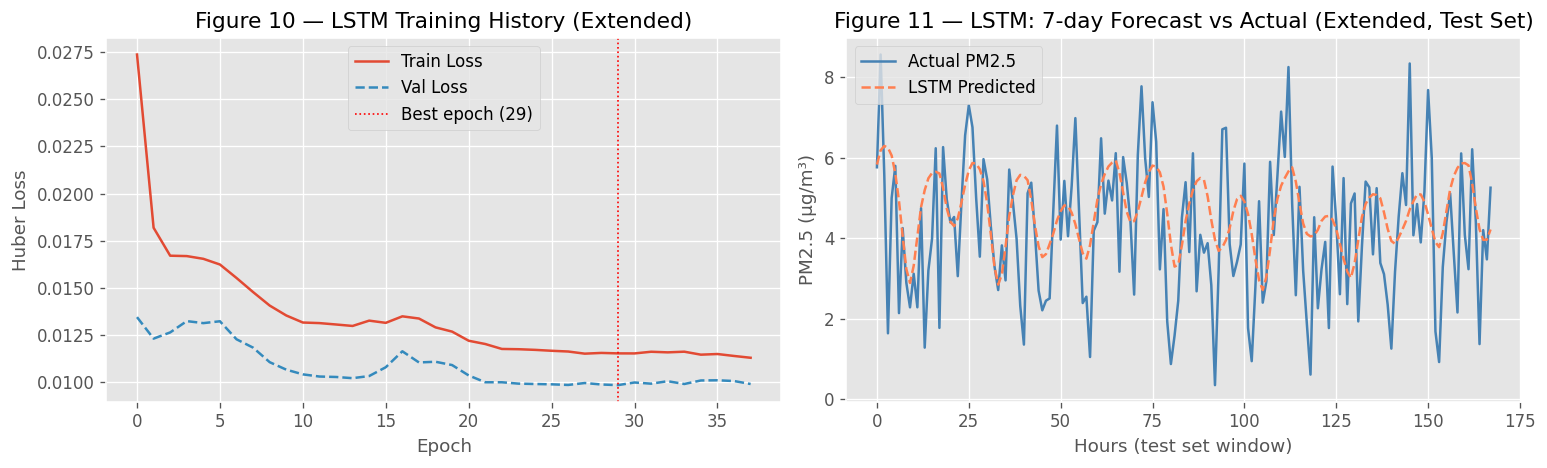

In [ ]:
if not sim_weather.empty:
    # ── Training history ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_sim.history['loss'],     lw=1.5, label='Train Loss')
    axes[0].plot(history_sim.history['val_loss'], lw=1.5, ls='--', label='Val Loss')
    best_ep = np.argmin(history_sim.history['val_loss'])
    axes[0].axvline(best_ep, color='red', ls=':', lw=1, label=f'Best epoch ({best_ep})')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
    axes[0].set_title('LSTM Training History (Extended)')
    axes[0].legend()

    # Time-series comparison — 7-day window from test set
    n_plot = min(168, len(y_te_orig))
    axes[1].plot(y_te_orig[:n_plot],      lw=1.5, color='steelblue', label='Actual PM2.5')
    axes[1].plot(lstm_pred_orig[:n_plot], lw=1.5, color='coral', ls='--', label='LSTM Predicted')
    axes[1].set_xlabel('Hours (test set window)')
    axes[1].set_ylabel('PM2.5 (µg/m³)')
    axes[1].set_title('LSTM: 7-day Forecast vs Actual (Extended, Test Set)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 11. Real vs Synthetic



  FINAL MODEL PERFORMANCE SUMMARY


,MAE (µg/m³),RMSE (µg/m³),R²,MAPE (%)
Model,,,,
RF (real data — 14 days),5.0999,7.3061,0.7347,29.4457
LSTM (real data — 14 days),11.5981,17.1252,-0.5544,64.5310
RF (extended — full year),1.2340,1.5613,0.2512,71.9467
LSTM (extended — full year),1.2806,1.6158,0.1968,75.2426


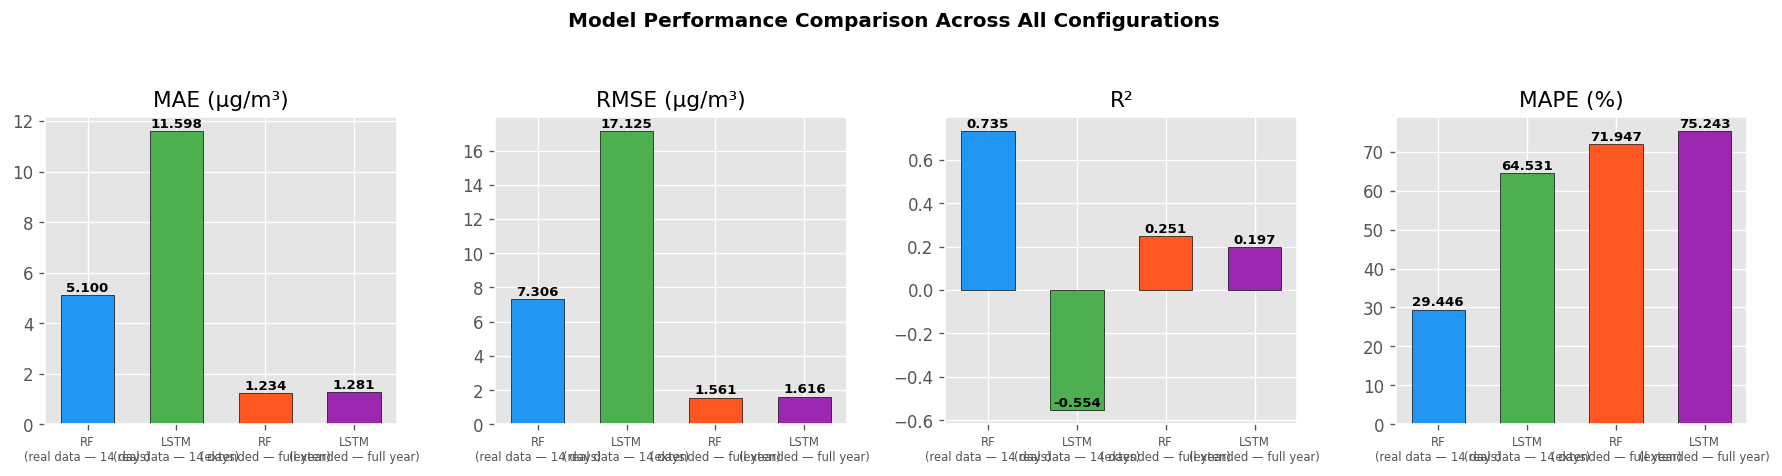

In [ ]:
results = []

try:
    results.append({'Model': 'RF (real data — 14 days)',    **rf_real_metrics})
except: pass
try:
    results.append({'Model': 'LSTM (real data — 14 days)',  **lstm_real_metrics})
except: pass
try:
    results.append({'Model': 'RF (extended — full year)',   **rf_sim_metrics})
except: pass
try:
    results.append({'Model': 'LSTM (extended — full year)', **lstm_sim_metrics})
except: pass

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.rename(columns={
    'mae': 'MAE (µg/m³)', 'rmse': 'RMSE (µg/m³)', 'r2': 'R²', 'mape': 'MAPE (%)'
})
print("\n" + "="*70)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("="*70)
display(results_df.round(4))
if len(results) >= 2:
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    metrics_plot = ['MAE (µg/m³)', 'RMSE (µg/m³)', 'R²', 'MAPE (%)']
    colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0'][:len(results_df)]

    for ax, metric in zip(axes, metrics_plot):
        bars = ax.bar(range(len(results_df)), results_df[metric],
                      color=colors, edgecolor='k', lw=0.4, width=0.6)
        ax.set_xticks(range(len(results_df)))
        ax.set_xticklabels([m.replace(' (', '\n(') for m in results_df.index],
                           fontsize=7, rotation=0, ha='center')
        ax.set_title(metric)
        for bar, v in zip(bars, results_df[metric]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002 * results_df[metric].max(),
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    fig.suptitle('Model Performance Comparison Across All Configurations',
                 fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
